In [15]:
# ==========================================================
# CELL 1 — SciBERT Topic Modelling with Heavy Domain Cleaning
# ==========================================================

import os, re, pickle
import numpy as np
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from scipy import sparse

os.makedirs("../models", exist_ok=True)
print("Saving artefacts to ../models/...")

# ----------------------------------------------------------
# 1. Load dataset
# ----------------------------------------------------------
df = pd.read_excel(
    '../data/dimensions/api/raw/combined/202511/df_dimensions.xlsx',
    index_col=0
)

# ----------------------------------------------------------
# 2. Clean text
# ----------------------------------------------------------
def clean_abstract(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s\-]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["abstract_clean"] = df["abstract"].astype(str).apply(clean_abstract)
abstracts = df["abstract_clean"].tolist()

pickle.dump(abstracts, open("../models/cleaned_abstracts.pkl", "wb"))
print(f"Loaded {len(abstracts)} cleaned abstracts.")

# ----------------------------------------------------------
# 3. SciBERT sentence embeddings
# ----------------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

model_name = "gsarti/scibert-nli"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)
model.eval()

def encode_batch(texts, batch_size=16):
    vecs = []
    total = (len(texts)-1)//batch_size + 1
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, return_tensors="pt", padding=True,
                        truncation=True, max_length=256).to(device)
        with torch.no_grad():
            out = model(**enc)
            mask = enc["attention_mask"].unsqueeze(-1)
            pooled = (out.last_hidden_state * mask).sum(1) / mask.sum(1)
            vecs.append(pooled.cpu().numpy())
        print(f"Batch {i//batch_size+1}/{total}", end="\r")
    print("")
    return np.vstack(vecs)

print("Encoding SciBERT embeddings...")
X = encode_batch(abstracts)

pickle.dump(X, open("../models/embeddings.npy", "wb"))
print(f"Embeddings saved: shape {X.shape}")

# ----------------------------------------------------------
# 4. Auto-select K from {12,16,20}
# ----------------------------------------------------------
candidate_K = [12, 16, 20]
results = []

print("Evaluating K candidates:")
for k in candidate_K:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X)
    sil = silhouette_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    db = davies_bouldin_score(X, labels)
    results.append((k, sil, ch, db))
    print(f"K={k} | Sil={sil:.3f} | CH={ch:.0f} | DB={db:.3f}")

best_k = sorted(results, key=lambda x: (x[1], x[2]), reverse=True)[0][0]
pickle.dump(best_k, open("../models/best_k.pkl", "wb"))
print(f"Selected K = {best_k}")

# ----------------------------------------------------------
# 5. Fit final clustering
# ----------------------------------------------------------
kmeans = KMeans(n_clusters=best_k, n_init=20, random_state=42)
clusters = kmeans.fit_predict(X)
df["cluster"] = clusters

pickle.dump(clusters, open("../models/cluster_assignments.pkl", "wb"))

# ----------------------------------------------------------
# 6. Topic docs
# ----------------------------------------------------------
topic_docs = (
    df.groupby("cluster")["abstract_clean"]
      .apply(lambda s: " ".join(s))
      .sort_index()
      .tolist()
)

# ----------------------------------------------------------
# 7. EXTREME stopword removal
# ----------------------------------------------------------
biomed_stop = {
    # statistical junk
    "p value","pvalue",
    "association","effect","effects","estimate","estimated",
    "hr","ci","hazard","hazard ratio","hazard ratios","odds","odds ratio",
    "or","beta","coeff","coefficient","coefficients","model","models",
    "adjusted","significant","significance",
    # generic scientific junk
    "analysis","analyses","study","studies","sample","samples",
    "population","participants","cohort","baseline","follow","follow up",
    "results","data","using","measured",
    # pure noise
    "increase","decrease","higher","lower",
}

stopwords = list(ENGLISH_STOP_WORDS.union(biomed_stop))

# ----------------------------------------------------------
# 8. c-TF-IDF vectorizer
# ----------------------------------------------------------
vectorizer = TfidfVectorizer(
    max_features=7000,
    stop_words=stopwords,
    ngram_range=(1,2),
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z\-]+\b"    # remove numeric + rubbish n-grams
)

c_tfidf = vectorizer.fit_transform(topic_docs)

sparse.save_npz("../models/c_tfidf.npz", c_tfidf)
feature_names = np.array(vectorizer.get_feature_names_out(), dtype="<U100")

pickle.dump(feature_names.tolist(), open("../models/feature_names.pkl", "wb"))
pickle.dump(vectorizer, open("../models/vectorizer.pkl", "wb"))

# ----------------------------------------------------------
# 9. Topic naming (contrastive, ≤20 chars)
# ----------------------------------------------------------
dense = c_tfidf.toarray()
global_mean = dense.mean(axis=0)
topic_labels = {}

print("\n=== Topic naming (cleaned, ≤20 chars) ===")
for c in range(best_k):
    contrast = dense[c] - global_mean
    idx = contrast.argsort()[::-1][:4]
    phrase = ", ".join(feature_names[idx])
    phrase = phrase[:20]  # enforce length
    topic_labels[c] = phrase
    print(f"Topic {c}: {phrase}")

pickle.dump(topic_labels, open("../models/topic_labels.pkl", "wb"))

print("\n=== CELL 1 DONE ===")


Saving artefacts to ../models/...
Loaded 10846 cleaned abstracts.
Encoding SciBERT embeddings...
Batch 678/678
Embeddings saved: shape (10846, 768)
Evaluating K candidates:
K=12 | Sil=0.056 | CH=431 | DB=3.023
K=16 | Sil=0.049 | CH=342 | DB=3.202
K=20 | Sil=0.045 | CH=287 | DB=3.358
Selected K = 12


/home/porco/miniforge3/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ratio', 'ratios', 'value'] not in stop_words.
  warnings.warn(



=== Topic naming (cleaned, ≤20 chars) ===
Topic 0: women, risk, years, 
Topic 1: variants, genetic, g
Topic 2: associated, dietary,
Topic 3: nan nan, nan, articl
Topic 4: genetic, genes, iden
Topic 5: prediction, performa
Topic 6: risk, cancer, associ
Topic 7: method, genetic, met
Topic 8: brain, cognitive, de
Topic 9: risk, increased, dem
Topic 10: sub, risk, years, su
Topic 11: risk, mortality, act

=== CELL 1 DONE ===


Loaded embeddings (10846, 768), k=12


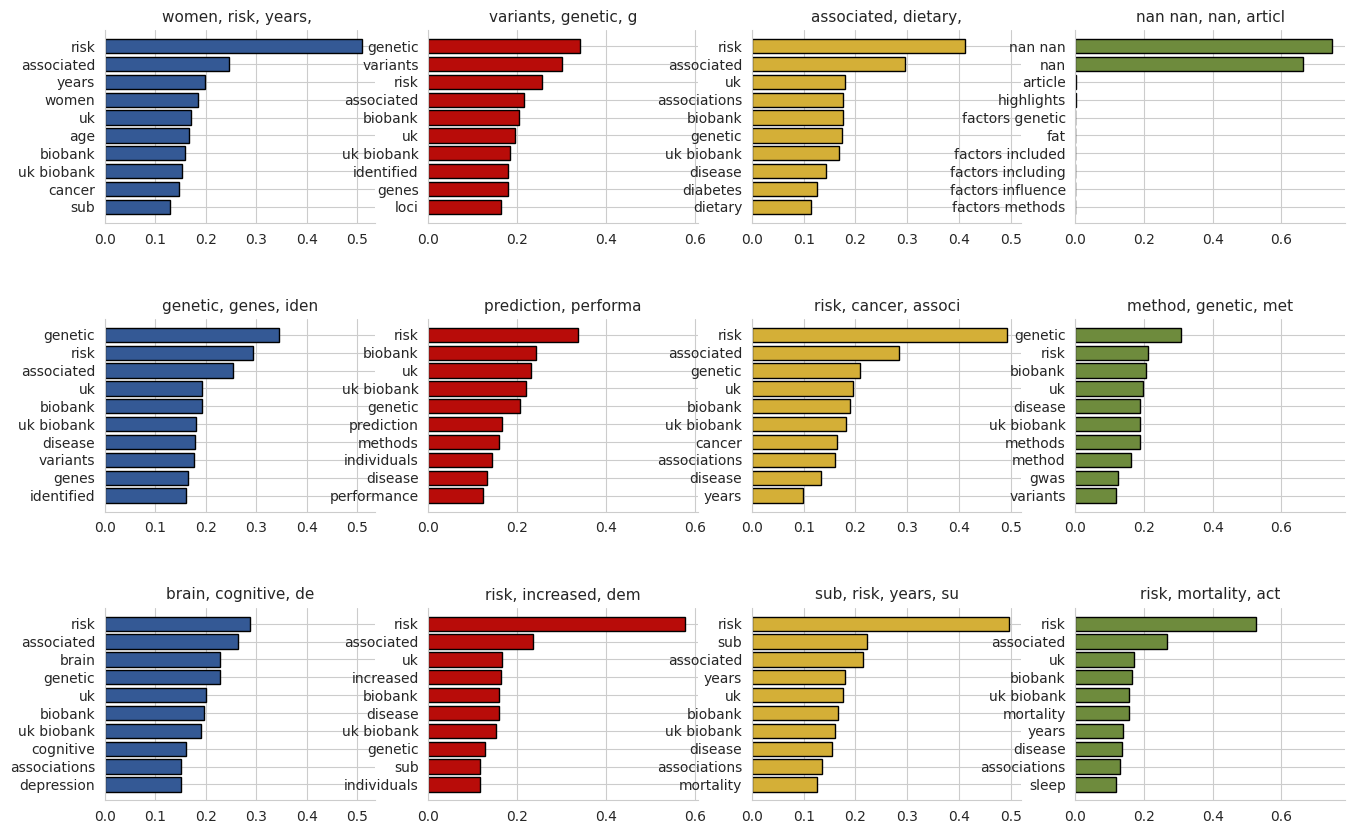

In [16]:
# ============================================
# CELL 2 — Load Saved Models & Plot Topics
# ============================================

import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse

# --------------------------------------------
# Load artefacts
# --------------------------------------------
X = pickle.load(open("../models/embeddings.npy", "rb"))
clusters = pickle.load(open("../models/cluster_assignments.pkl", "rb"))
best_k = pickle.load(open("../models/best_k.pkl", "rb"))
topic_labels = pickle.load(open("../models/topic_labels.pkl", "rb"))
feature_names = np.array(pickle.load(open("../models/feature_names.pkl", "rb")))
vectorizer = pickle.load(open("../models/vectorizer.pkl", "rb"))
c_tfidf = sparse.load_npz("../models/c_tfidf.npz")

print(f"Loaded embeddings {X.shape}, k={best_k}")

# --------------------------------------------
# helper
# --------------------------------------------
def top_keywords(topic_idx, top_n=10):
    row = c_tfidf[topic_idx].toarray().ravel()
    idx = row.argsort()[::-1][:top_n]
    return feature_names[idx], row[idx]

# --------------------------------------------
# Plotting topics
# --------------------------------------------
cols = 4
k = best_k
rows = int(np.ceil(k / cols))

regal_colors = ["#345995", "#B80C09", "#D4AF37", "#6E8B3D"]

fig, axes = plt.subplots(rows, cols, figsize=(16, 10))
axes = axes.flatten()

# share x-axis within each column only
for col in range(cols):
    column_axes = axes[col::cols]
    for ax in column_axes[1:]:
        ax.sharex(column_axes[0])

for c in range(k):
    words, weights = top_keywords(c, top_n=10)
    ax = axes[c]
    ax.barh(words[::-1], weights[::-1],
            color=regal_colors[c % 4],
            edgecolor="black")
    ax.set_title(topic_labels[c], fontsize=11)

# hide unused
for j in range(k, rows * cols):
    axes[j].axis("off")

plt.subplots_adjust(hspace=0.5)
sns.despine()
plt.show()
